In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [15]:
retail = pd.read_csv('../Data/cleaned_data.csv')

In [16]:
retail.shape

(7914, 21)

In [17]:
retail.head()

,transaction_id,customer_id,customer_name,product_id,price,product_name,category,purchase_location,city,transaction_date,quantity,payment_method,discount,email,phone,payment_status,revenue,year,month,month_name,quarter
0,1,642,Troy Mitchell,108,15000.0,Mixer Grinder,Home Appliances,offline,Bangalore,2025-12-06,3,UPI,0.10,T***@gmail.com,******6968,successful,40500.0,2025,12,December,4
1,2,881,Sarah Guerrero,102,70000.0,Phone,Electronics,online,Bangalore,2025-07-21,5,Card,0.35,S***@yahoo.com,******8911,successful,227500.0,2025,7,July,3
2,3,505,Samantha Hull,109,65000.0,Refrigerator,Home Appliances,offline,Chennai,2025-07-11,2,UPI,0.05,S***@outlook.com,******1565,successful,123500.0,2025,7,July,3
3,4,794,Gerald Cooper,106,80000.0,Sofa,Furniture,offline,Chennai,2025-10-06,2,UPI,0.05,G***@gmail.com,******4201,successful,152000.0,2025,10,October,4
4,5,864,Cameron Black,108,15000.0,Mixer Grinder,Home Appliances,offline,Chennai,2025-12-12,1,Cash,0.05,C***@yahoo.com,******9477,successful,14250.0,2025,12,December,4


In [18]:
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7914 entries, 0 to 7913
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     7914 non-null   int64  
 1   customer_id        7914 non-null   int64  
 2   customer_name      7914 non-null   object 
 3   product_id         7914 non-null   int64  
 4   price              7914 non-null   float64
 5   product_name       7914 non-null   object 
 6   category           7914 non-null   object 
 7   purchase_location  7914 non-null   object 
 8   city               7914 non-null   object 
 9   transaction_date   7914 non-null   object 
 10  quantity           7914 non-null   int64  
 11  payment_method     7914 non-null   object 
 12  discount           7914 non-null   float64
 13  email              7914 non-null   object 
 14  phone              7914 non-null   object 
 15  payment_status     7914 non-null   object 
 16  revenue            7914 

In [19]:
total_revenue=retail['revenue'].sum()
print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 1,163,993,285.00


In [20]:
total_orders=retail['transaction_id'].nunique()
print("Total Orders:",total_orders)

Total Orders: 7914


In [21]:
total_customers=retail['customer_id'].nunique()
print("Total_customers",total_customers)

Total_customers 1960


In [22]:
avg_order=(retail['revenue'].sum()/retail['transaction_id'].nunique())

In [23]:
print(f"Average Order Value: {avg_order:,.2f}")

Average Order Value: 147,080.27


In [24]:
revenue_by_category = (retail.groupby('category')['revenue'].sum().sort_values(ascending=False))
revenue_by_category

category
Electronics        674462500.0
Furniture          243413000.0
Home Appliances    229025250.0
Clothing            17092535.0
Name: revenue, dtype: float64

In [25]:
revenue_by_city = (retail.groupby('city')['revenue'].sum().sort_values(ascending=False))
revenue_by_city

city
Chennai      246028300.0
Delhi        242022530.0
Hyderabad    232881480.0
Mumbai       226340465.0
Bangalore    216720510.0
Name: revenue, dtype: float64

In [26]:
top_products = (retail.groupby('product_name')['revenue'].sum().sort_values(ascending=False))
top_products.head(10)

product_name
Laptop           466250000.0
Sofa             150708000.0
Phone            127568000.0
Refrigerator     117975000.0
Dining Table      92705000.0
Microwave         83659500.0
Tv                80644500.0
Mixer Grinder     27390750.0
Shoes             14864400.0
Shirt              2228135.0
Name: revenue, dtype: float64

In [27]:
payment_revenue = (retail.groupby('payment_method')['revenue'].sum().sort_values(ascending=False))
payment_revenue

payment_method
Card          302321530.0
Cash          297436650.0
UPI           291428345.0
NetBanking    272806760.0
Name: revenue, dtype: float64

In [28]:
monthly_revenue = (retail.groupby('month_name')['revenue'].sum())
monthly_revenue

month_name
April         95548875.0
August       104185080.0
December      90777395.0
February      95013770.0
January       95705715.0
July          99087055.0
June          99173500.0
March         91921520.0
May           99328565.0
November      92090715.0
October      101016795.0
September    100144300.0
Name: revenue, dtype: float64

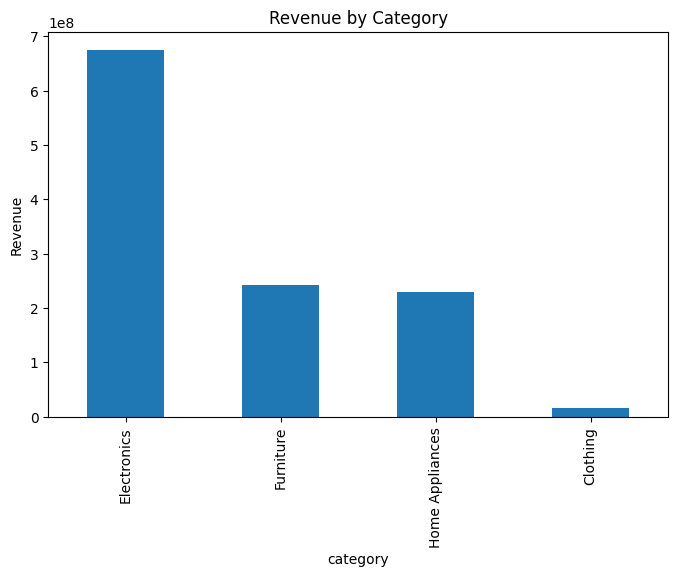

In [29]:
revenue_by_category.plot(kind='bar',figsize=(8,5))

plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.show()

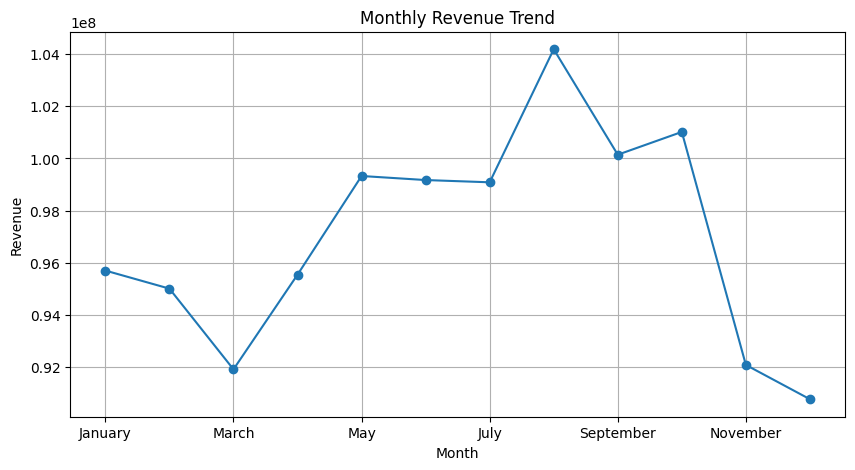

In [30]:
monthly_revenue = (retail.groupby('month_name')['revenue'].sum())
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_revenue = monthly_revenue.reindex(month_order)
monthly_revenue.plot(kind='line',marker='o',figsize=(10,5))

plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xlabel("Month")
plt.grid(True)
plt.show()

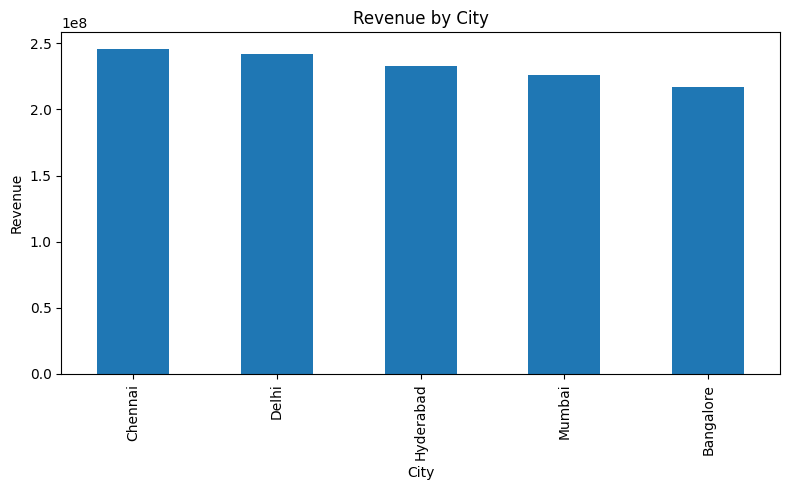

In [31]:
revenue_by_city = (
    retail.groupby('city')['revenue']
    .sum()
    .sort_values(ascending=False)
)

revenue_by_city.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Revenue by City")
plt.ylabel("Revenue")
plt.xlabel("City")
plt.tight_layout()
plt.show()

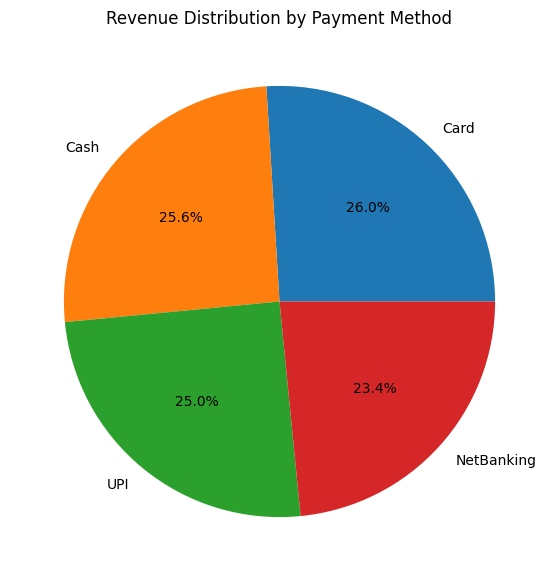

In [32]:
payment_revenue = (retail.groupby('payment_method')['revenue'].sum().sort_values(ascending=False))
payment_revenue.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title("Revenue Distribution by Payment Method")
plt.ylabel("")
plt.show()